In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pydot

# Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [2]:
#!pip install pydot

In [3]:
#!pip install tensorflow

In [4]:
#!pip install scikeras

In [5]:
#digit MNIST dataset
(X_train_digit, y_train_digit),(X_test_digit, y_test_digit) = mnist.load_data()

In [6]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

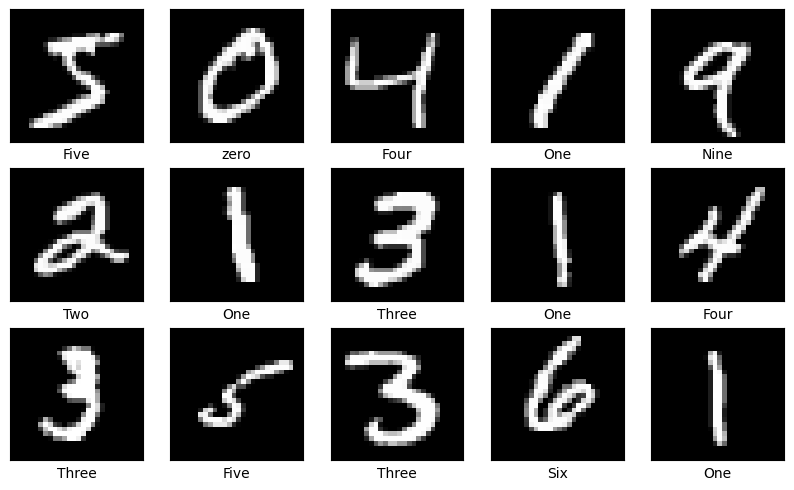

In [7]:
# Names of numbers in the dataset in order
col_names = ["zero", "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine"]

#visualizing the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

In [8]:
X_train_digit.shape

(60000, 28, 28)

In [9]:
# convert 3D to 2D
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [10]:
X_train_digit.shape

(60000, 784)

In [11]:
y_test_digit.shape

(10000,)

In [12]:
# Encoding Output
y_train_digit = to_categorical(y_train_digit, num_classes = 10)
y_test_digit = to_categorical(y_test_digit, num_classes = 10)

In [13]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [14]:
#creating base neural network
model = keras.Sequential([
    # First hidden layer with 256 neurons and ReLU activation
    layers.Dense(256, activation='relu', input_shape=(784,)),
    # Randomly drop some neurons to reduce overfitting
    layers.Dropout(0.3),
    # Normalize data to improve training and accuracy
    layers.BatchNormalization(),
    # Second hidden layer with 64 neurons
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    # Third hidden layer with 64 neurons
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    # Output layer with 10 neurons for digits 0-9
    layers.Dense(10, activation='sigmoid')
])

C:\Users\Raji\anaconda3\envs\aiml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# param = number of output channel * (number of input channel + 1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 223,754 (874.04 KB)

 Trainable params: 222,986 (871.04 KB)

 Non-trainable params: 768 (3.00 KB)

In [16]:
# compiling - Prepare the model for training by defining: error calculation, learning method, evaluation metric
model.compile(loss = "categorical_crossentropy",
              optimizer = "adam",
              metrics =["accuracy"])

In [17]:
history = model.fit(X_train_digit, y_train_digit, batch_size = 100, epochs=10, validation_data = (X_test_digit, y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8345 - loss: 0.5526 - val_accuracy: 0.9560 - val_loss: 0.1484
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9301 - loss: 0.2461 - val_accuracy: 0.9668 - val_loss: 0.1113
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9465 - loss: 0.1899 - val_accuracy: 0.9681 - val_loss: 0.1062
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9535 - loss: 0.1669 - val_accuracy: 0.9734 - val_loss: 0.0894
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9588 - loss: 0.1473 - val_accuracy: 0.9734 - val_loss: 0.0951
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9622 - loss: 0.1327 - val_accuracy: 0.9741 - val_loss: 0.0924
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9653 - loss: 0.1251 - val_accuracy: 0.9766 - val_loss: 0.0842
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9668 - loss: 0.1156 - val_accuracy: 0.

In [18]:
y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [19]:
# Convert predicted probabilities into class labels
y_predicts = np.argmax(y_predict, axis=1)
# Convert one-hot encoded test labels into actual digit labels
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

In [20]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [21]:
y_predicts

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

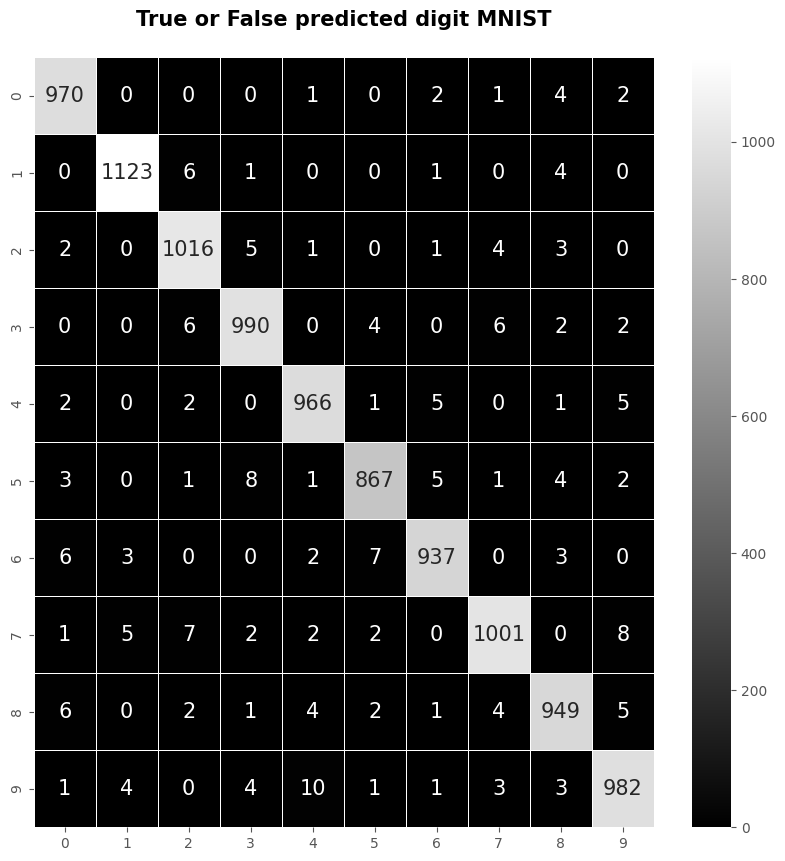

In [22]:
# Create confusion matrix using actual and predicted labels
con_mat = confusion_matrix(y_test_digit_eval, y_predicts)
plt.style.use("ggplot")
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size': 15}, linewidths=0.5, fmt="d", cmap ="gray")
plt.title("True or False predicted digit MNIST\n", fontweight='bold', fontsize=15)
plt.show()

In [23]:
#See all available styles in installation:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



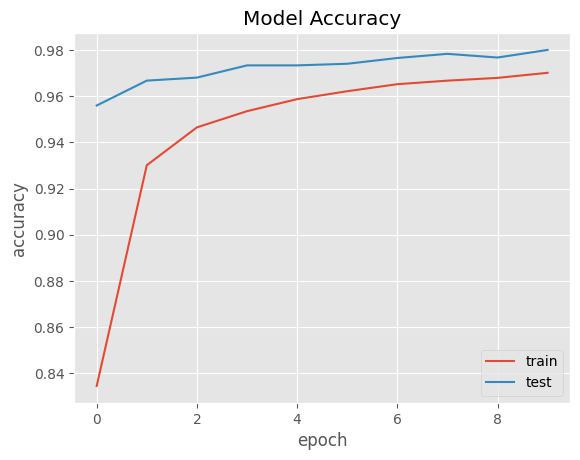

In [25]:
# graph for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

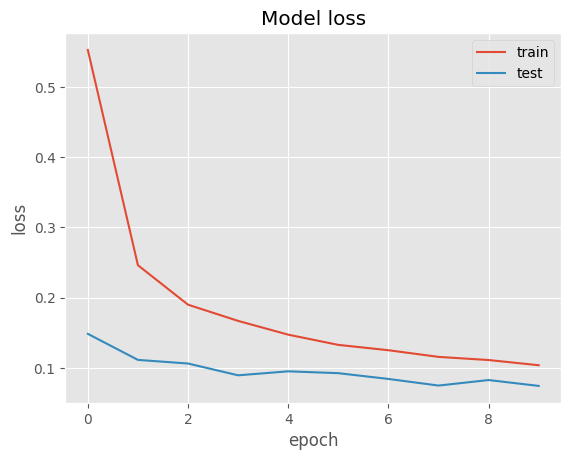

In [26]:
# graph for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

In [27]:
# Predict digit probabilities for one test image
y_predict_single = model.predict(X_test_digit[[1]])

# Get predicted digit label (highest probability)
y_predicts_single = np.argmax(y_predict_single, axis=1)

# Convert actual test label from one-hot to digit label
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [28]:
y_predict_single

array([[0.50440824, 0.84184134, 0.9999825 , 0.41819206, 0.5862528 ,
        0.0323842 , 0.49895123, 0.6704273 , 0.36066645, 0.01651675]],
      dtype=float32)

In [29]:
y_predicts_single

array([2], dtype=int64)

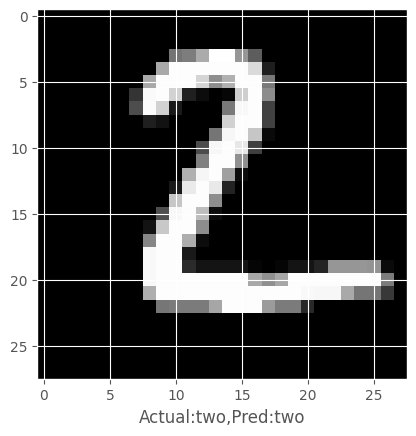

In [31]:
#Digit names
col_names = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
# Show the test image
plt.imshow(X_test_digit[1].reshape(28,28), cmap='gray')
# Display actual and predicted digit labels
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[1])],col_names[y_predicts_single[0]]))
plt.show()